In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")


In [4]:
df = pd.read_excel('/Users/swaransh/Downloads/Flight_dataset[4039] (1).xlsx')

df = df.drop(columns=['Unnamed: 0', 'flight'])

df.shape

(300153, 10)

In [5]:
print(df.isnull().sum())

airline              0
source_city          0
departure_time       0
stops                0
arrival_time         0
destination_city     0
class                0
duration            12
days_left            5
price                5
dtype: int64


In [6]:
df = df.dropna(subset=['price'])

df['duration'] = df['duration'].fillna(df['duration'].median())
df['days_left'] = df['days_left'].fillna(df['days_left'].median())

print("\nBasic Statistics:")
print(df[['price', 'duration', 'days_left']].describe().round(2))
df.shape


Basic Statistics:
           price   duration  days_left
count  300148.00  300148.00  300148.00
mean    20889.76      12.22      26.01
std     22697.93       7.19      13.56
min      1105.00       0.83       1.00
25%      4783.00       6.83      15.00
50%      7425.00      11.25      26.00
75%     42521.00      16.17      38.00
max    123071.00      49.83      49.00


(300148, 10)

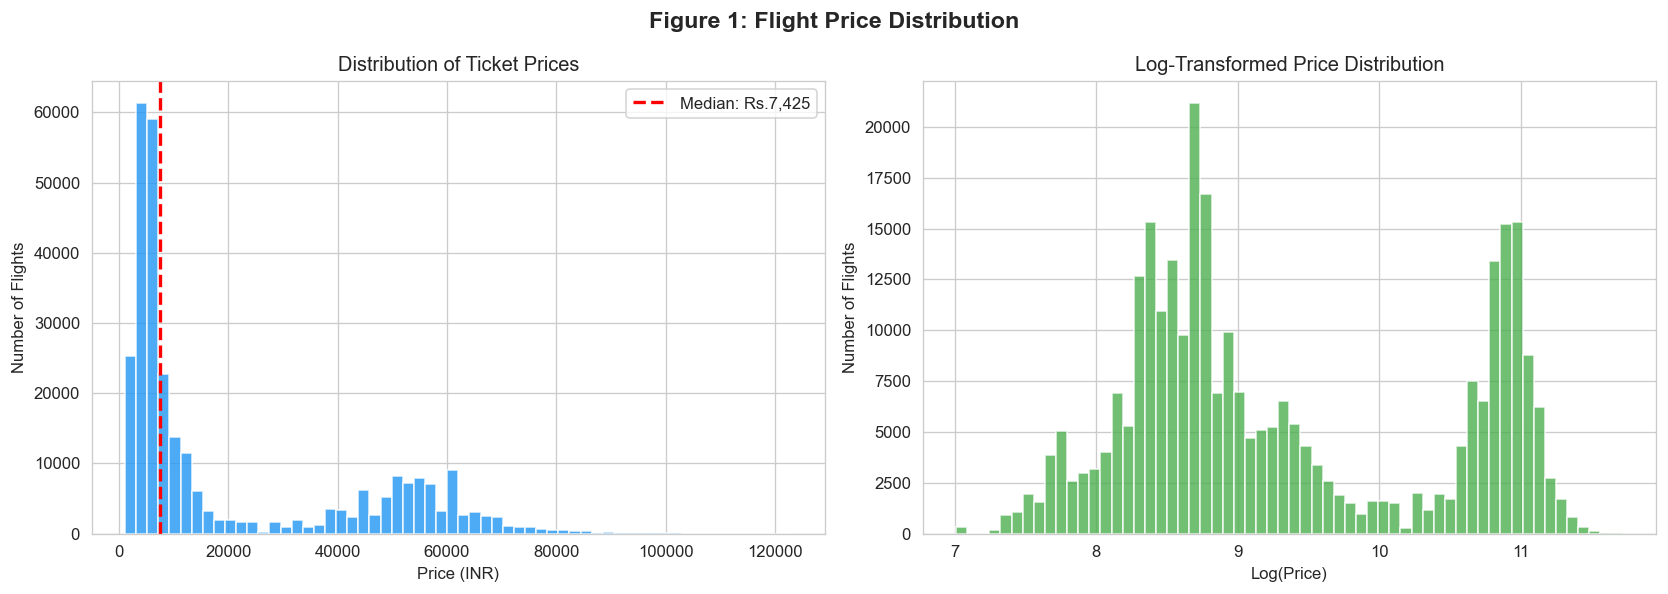

In [31]:
# FIGURE 1: Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1: Flight Price Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df['price'], bins=60, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Ticket Prices')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Number of Flights')
axes[0].axvline(df['price'].median(), color='red', linestyle='--', linewidth=2,
                label=f"Median: Rs.{df['price'].median():,.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df['price']), bins=60, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Number of Flights')

plt.tight_layout()
plt.savefig('fig1_price_dist.png', bbox_inches='tight', dpi=150)
plt.show()

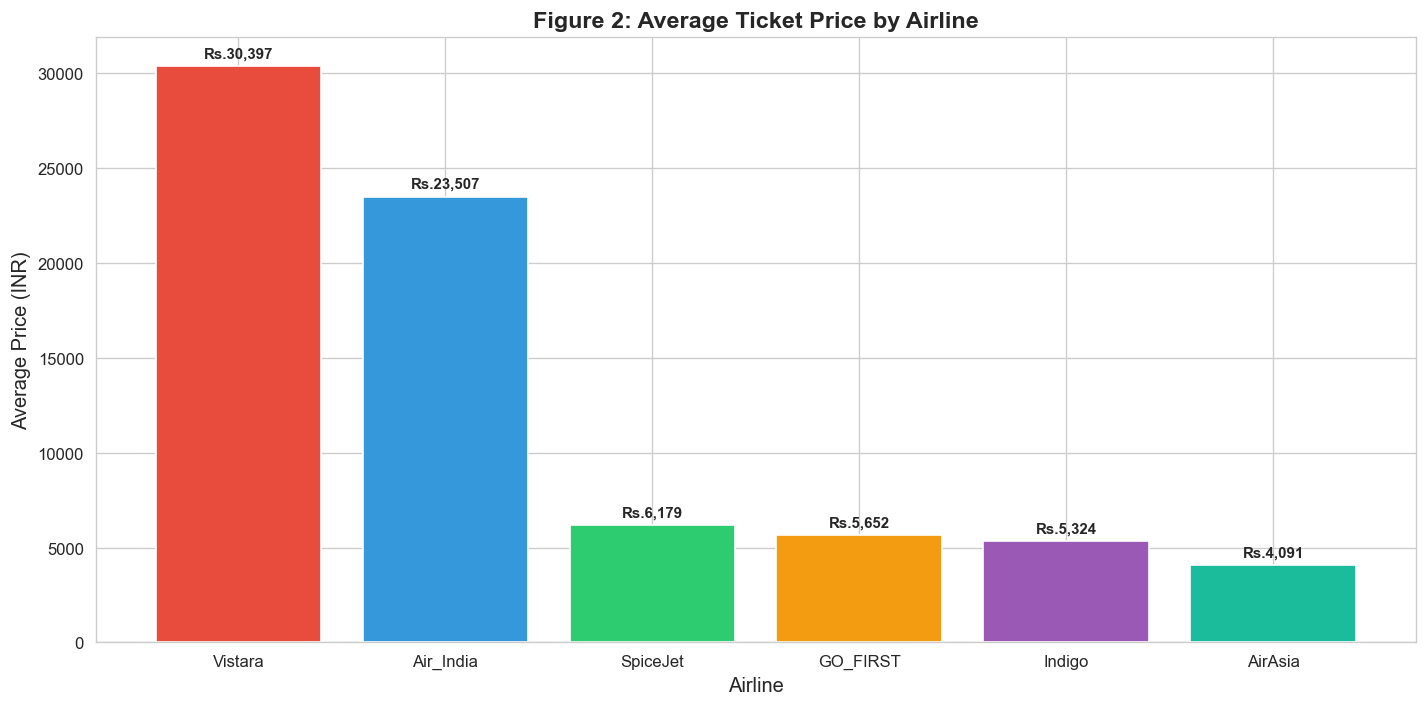

In [32]:
#  FIGURE 2: Average Price by Airline
fig, ax = plt.subplots(figsize=(12, 6))
avg_airline = df.groupby('airline')['price'].mean().sort_values(ascending=False)
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']
bars = ax.bar(avg_airline.index, avg_airline.values, color=colors, edgecolor='white')
ax.set_title('Figure 2: Average Ticket Price by Airline', fontsize=14, fontweight='bold')
ax.set_xlabel('Airline', fontsize=12)
ax.set_ylabel('Average Price (INR)', fontsize=12)
for bar, val in zip(bars, avg_airline.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'Rs.{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_airline_price.png', bbox_inches='tight', dpi=150)
plt.show()

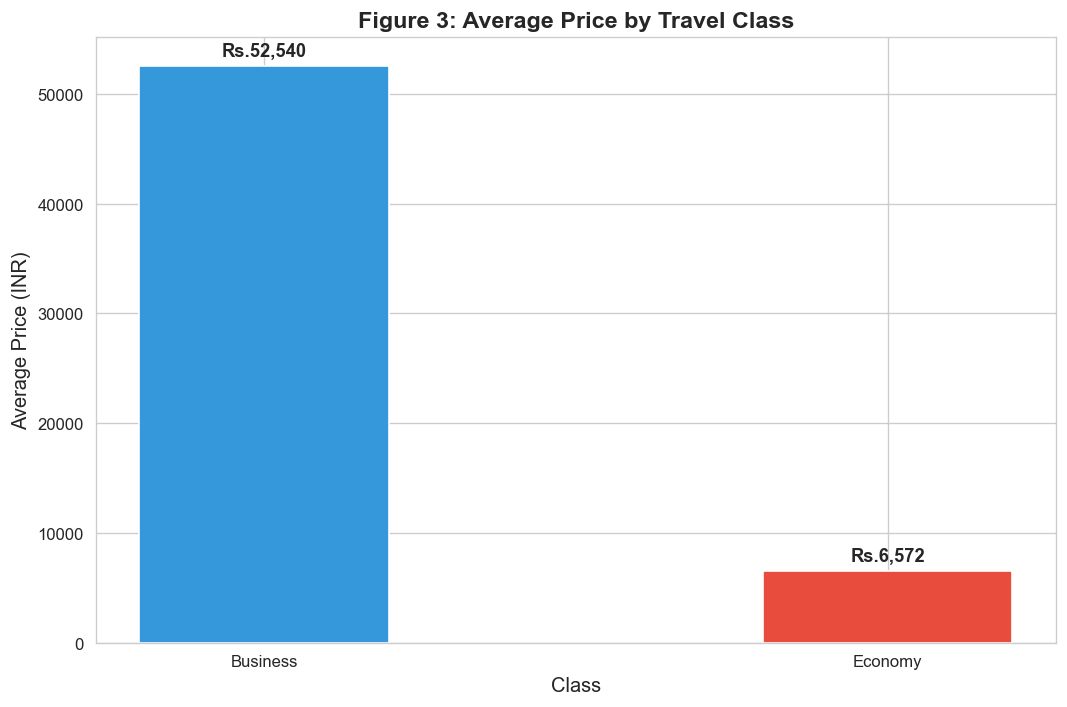

In [33]:
#  FIGURE 3: Economy vs Business Class
fig, ax = plt.subplots(figsize=(9, 6))
class_avg = df.groupby('class')['price'].mean()
colors_class = ['#3498DB', '#E74C3C']
bars = ax.bar(class_avg.index, class_avg.values, color=colors_class, width=0.4, edgecolor='white')
ax.set_title('Figure 3: Average Price by Travel Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Average Price (INR)', fontsize=12)
for bar, val in zip(bars, class_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'Rs.{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_class_price.png', bbox_inches='tight', dpi=150)
plt.show()

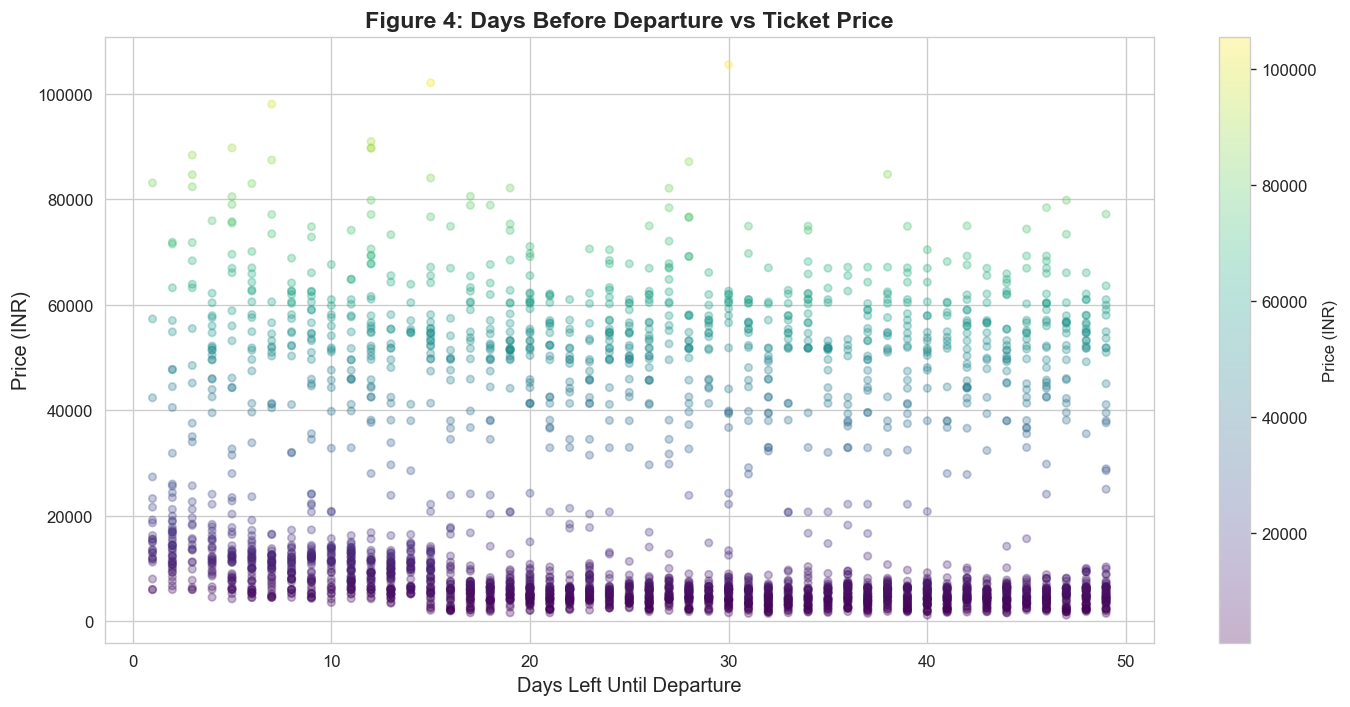

In [34]:
# FIGURE 4: Days Left vs Price
sample = df.sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(sample['days_left'], sample['price'], alpha=0.3,
                     c=sample['price'], cmap='viridis', s=20)
ax.set_title('Figure 4: Days Before Departure vs Ticket Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Days Left Until Departure', fontsize=12)
ax.set_ylabel('Price (INR)', fontsize=12)
plt.colorbar(scatter, ax=ax, label='Price (INR)')
plt.tight_layout()
plt.savefig('fig4_days_price.png', bbox_inches='tight', dpi=150)
plt.show()

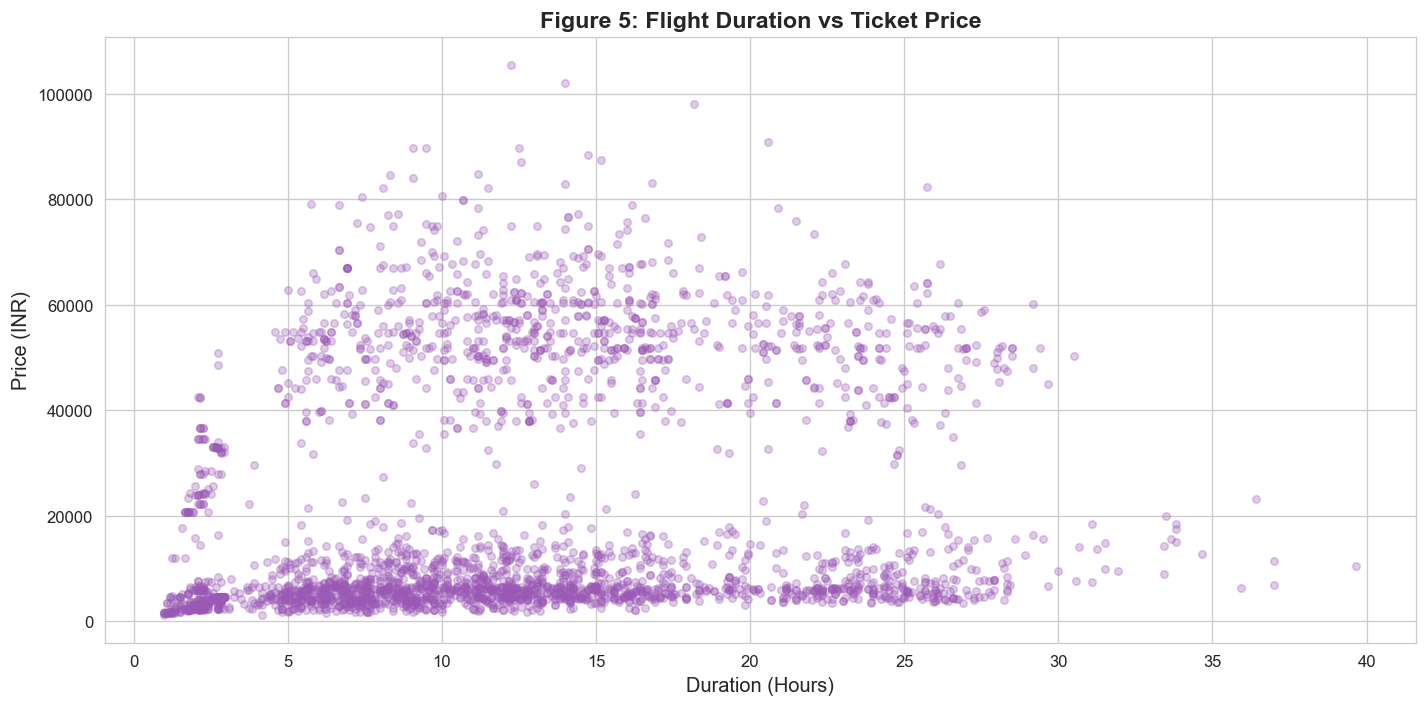

In [36]:
#  FIGURE 5: Duration vs Price
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(sample['duration'], sample['price'], alpha=0.3, color='#9B59B6', s=20)
ax.set_title('Figure 5: Flight Duration vs Ticket Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Duration (Hours)', fontsize=12)
ax.set_ylabel('Price (INR)', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_duration_price.png', bbox_inches='tight', dpi=150)
plt.show()


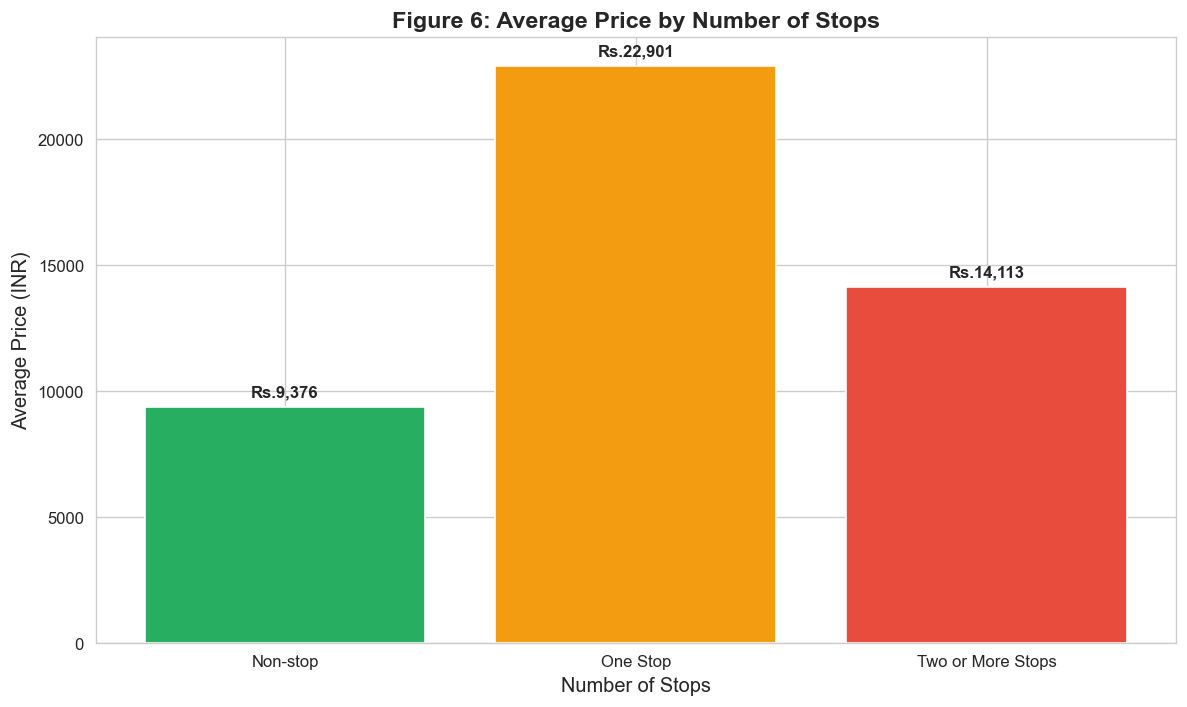

In [37]:
# FIGURE 6: Stops vs Price
fig, ax = plt.subplots(figsize=(10, 6))
stop_order = ['zero', 'one', 'two_or_more']
stop_labels = ['Non-stop', 'One Stop', 'Two or More Stops']
stop_avg = df.groupby('stops')['price'].mean().reindex(stop_order)
bars = ax.bar(stop_labels, stop_avg.values,
              color=['#27AE60', '#F39C12', '#E74C3C'], edgecolor='white')
ax.set_title('Figure 6: Average Price by Number of Stops', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Stops', fontsize=12)
ax.set_ylabel('Average Price (INR)', fontsize=12)
for bar, val in zip(bars, stop_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'Rs.{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_stops_price.png', bbox_inches='tight', dpi=150)
plt.show()

In [18]:
# STEP 5: HYPOTHESIS TESTING

def run_anova(column_name, label):
    groups = [group['price'].values for name, group in df.groupby(column_name)]
    f_stat, p_value = stats.f_oneway(*groups)
    significance = "SIGNIFICANT" if p_value < 0.05 else "NOT significant"
    print(f"  {label}: F={f_stat:.2f}, p-value={p_value:.6f} -> {significance}")
    return f_stat, p_value

results = {}
results['airline']        = run_anova('airline',        'Airline vs Price')
results['class']          = run_anova('class',          'Class vs Price')
results['stops']          = run_anova('stops',          'Stops vs Price')
results['source_city']    = run_anova('source_city',    'Source City vs Price')
results['departure_time'] = run_anova('departure_time', 'Departure Time vs Price')

print("\n  Pearson Correlation with Price:")
for col in ['duration', 'days_left']:
    corr, p = stats.pearsonr(df[col], df['price'])
    print(f"  {col}: r={corr:.4f}, p={p:.6f}")


[STEP 5] Conducting Hypothesis Tests (ANOVA)...
  Airline vs Price: F=17194.32, p-value=0.000000 -> SIGNIFICANT
  Class vs Price: F=2192449.30, p-value=0.000000 -> SIGNIFICANT
  Stops vs Price: F=6477.18, p-value=0.000000 -> SIGNIFICANT
  Source City vs Price: F=145.02, p-value=0.000000 -> SIGNIFICANT
  Departure Time vs Price: F=319.21, p-value=0.000000 -> SIGNIFICANT

  Pearson Correlation with Price:
  duration: r=0.2042, p=0.000000
  days_left: r=-0.0920, p=0.000000


In [38]:

# STEP 6: FEATURE ENGINEERING & ENCODING

df_model = df.copy()

le = LabelEncoder()
categorical_cols = ['airline', 'source_city', 'destination_city',
                    'departure_time', 'arrival_time']

for col in categorical_cols:
    df_model[col + '_encoded'] = le.fit_transform(df_model[col])

stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
df_model['stops_num'] = df_model['stops'].map(stops_map)

df_model['class_binary'] = (df_model['class'] == 'Business').astype(int)

feature_cols = [
    'airline_encoded',
    'source_city_encoded',
    'destination_city_encoded',
    'departure_time_encoded',
    'stops_num',
    'class_binary',
    'duration',
    'days_left'
]

X = df_model[feature_cols]
y = df_model['price']

print(f"  Features: {feature_cols}")
print(f"  Target: price")

  Features: ['airline_encoded', 'source_city_encoded', 'destination_city_encoded', 'departure_time_encoded', 'stops_num', 'class_binary', 'duration', 'days_left']
  Target: price


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [22]:
#MODEL 1 - LINEAR REGRESSION

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_r2   = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mape = mean_absolute_percentage_error(y_test, y_pred_lr) * 100
lr_rmsle = np.sqrt(mean_squared_error(
    np.log1p(y_test), np.log1p(np.abs(y_pred_lr))))

print(f"  R2 Score : {lr_r2:.4f}")
print(f"  RMSE     : Rs.{lr_rmse:,.2f}")
print(f"  MAPE     : {lr_mape:.2f}%")
print(f"  RMSLE    : {lr_rmsle:.4f}")

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n  Coefficients (effect on price per unit):")
print(coef_df.to_string(index=False))


[STEP 8] Training Model 1: Linear Regression...
  R2 Score : 0.9064
  RMSE     : Rs.6,945.74
  MAPE     : 41.78%
  RMSLE    : 0.6038

  Coefficients (effect on price per unit):
                 Feature  Coefficient
            class_binary 45065.122539
               stops_num  6092.753255
         airline_encoded   963.353795
destination_city_encoded   154.092589
     source_city_encoded   122.677980
  departure_time_encoded    80.632957
                duration    73.933096
               days_left  -129.402287


In [23]:
# MODEL 2 - RANDOM FOREST REGRESSOR

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mape = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
rf_rmsle = np.sqrt(mean_squared_error(
    np.log1p(y_test), np.log1p(y_pred_rf)))

print(f"  R2 Score : {rf_r2:.4f}")
print(f"  RMSE     : Rs.{rf_rmse:,.2f}")
print(f"  MAPE     : {rf_mape:.2f}%")
print(f"  RMSLE    : {rf_rmsle:.4f}")



[STEP 9] Training Model 2: Random Forest...
  (Training 100 trees, please wait...)
  R2 Score : 0.9780
  RMSE     : Rs.3,363.65
  MAPE     : 11.85%
  RMSLE    : 0.1786


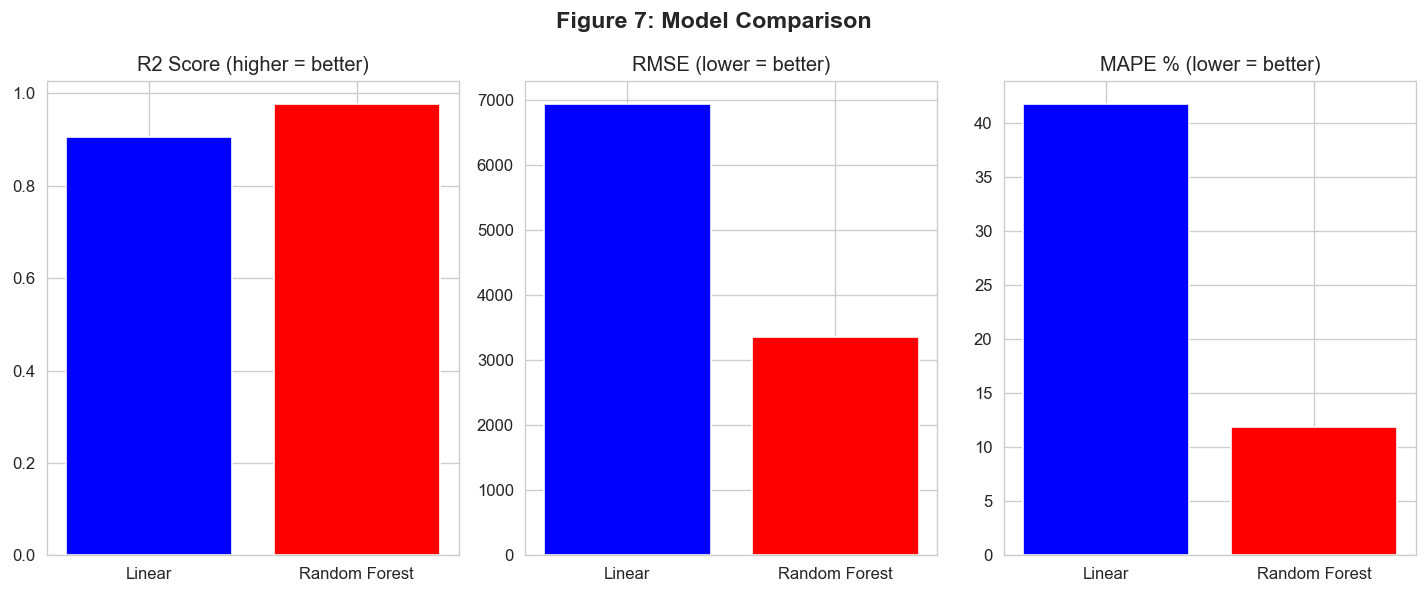

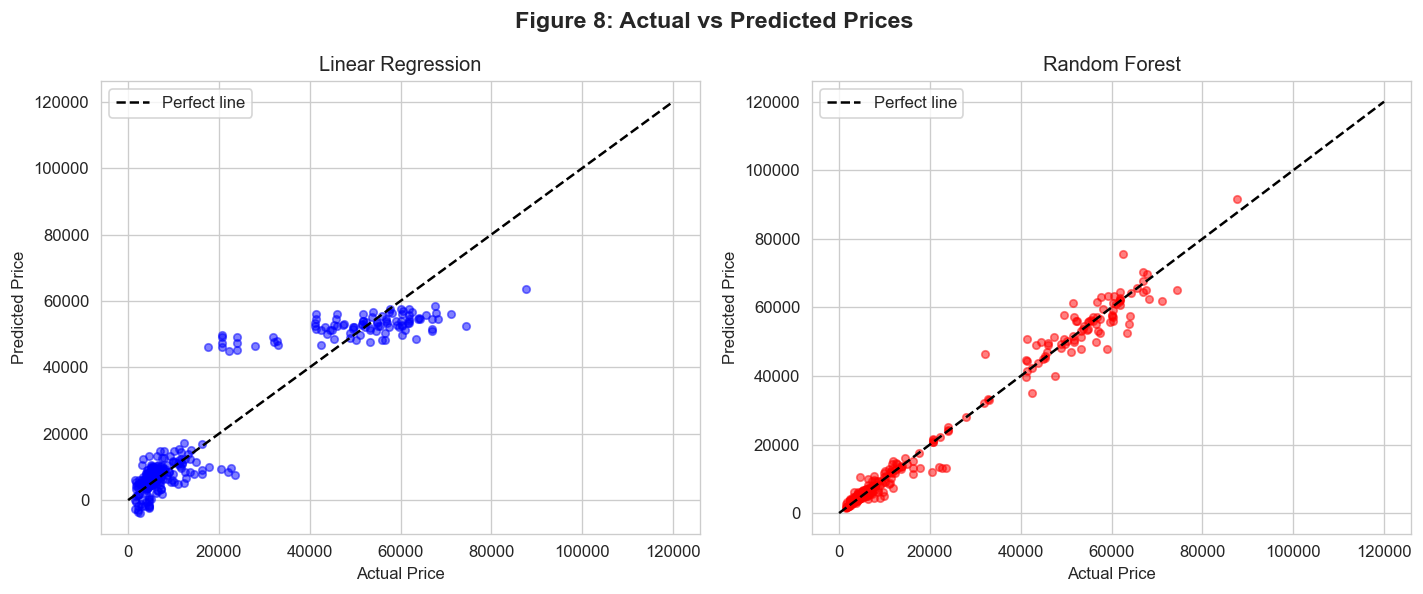

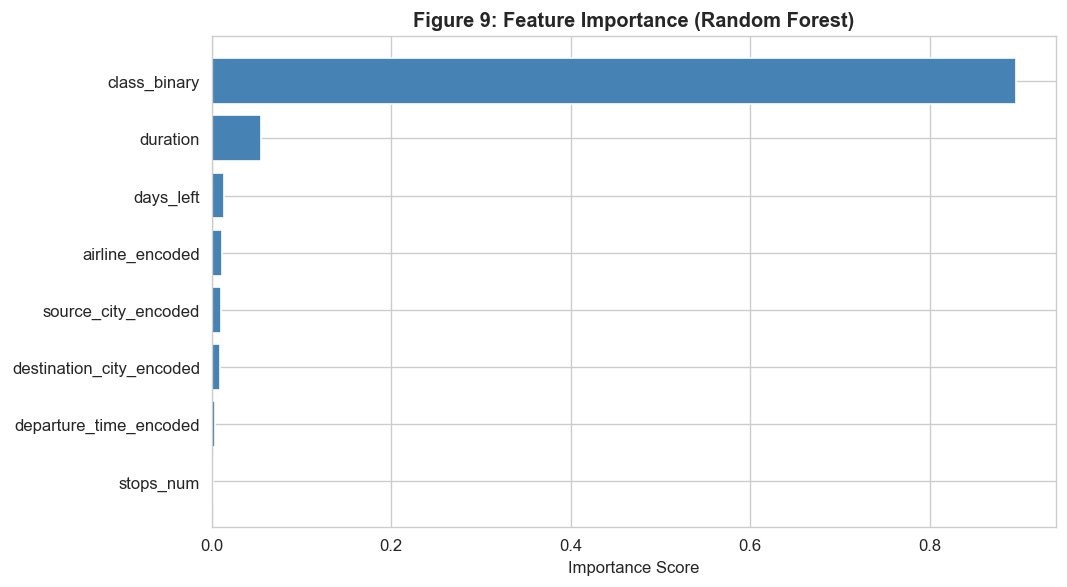

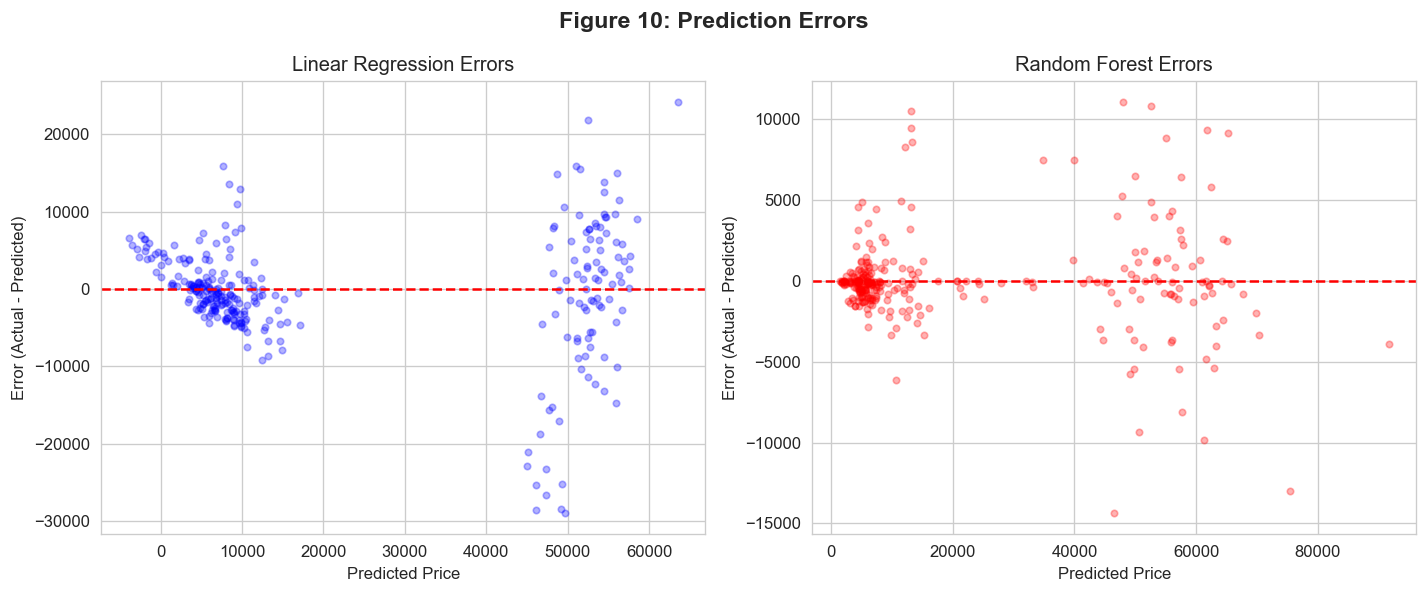


FINAL RESULTS
Linear Regression -> R2: 0.9064 | RMSE: Rs.6,946 | MAPE: 41.78%
Random Forest     -> R2: 0.9780 | RMSE: Rs.3,364 | MAPE: 11.85%


In [25]:
#SHOW RESULTS

#  FIGURE 7: Simple bar chart comparing both models
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Figure 7: Model Comparison', fontsize=14, fontweight='bold')

models = ['Linear', 'Random Forest']

axes[0].bar(models, [lr_r2, rf_r2], color=['blue', 'red'])
axes[0].set_title('R2 Score (higher = better)')

axes[1].bar(models, [lr_rmse, rf_rmse], color=['blue', 'red'])
axes[1].set_title('RMSE (lower = better)')

axes[2].bar(models, [lr_mape, rf_mape], color=['blue', 'red'])
axes[2].set_title('MAPE % (lower = better)')

plt.tight_layout()
plt.savefig('fig7_model_comparison.png')
plt.show()

# FIGURE 8: Did our predictions match real prices?
# sample of 300
sample_idx = np.random.choice(len(y_test), 300, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 8: Actual vs Predicted Prices', fontsize=14, fontweight='bold')

# Linear Regression chart
axes[0].scatter(y_test.values[sample_idx], y_pred_lr[sample_idx], alpha=0.5, color='blue', s=20)
axes[0].plot([0, 120000], [0, 120000], 'k--', label='Perfect line')
axes[0].set_title('Linear Regression')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].legend()

# Random Forest chart
axes[1].scatter(y_test.values[sample_idx], y_pred_rf[sample_idx], alpha=0.5, color='red', s=20)
axes[1].plot([0, 120000], [0, 120000], 'k--', label='Perfect line')
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig8_actual_vs_pred.png')
plt.show()

# FIGURE 9: Which features mattered most?
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance')

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
ax.set_title('Figure 9: Feature Importance (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig9_feature_importance.png')
plt.show()

#  FIGURE 10: How wrong were our predictions?
residuals_lr = y_test.values - y_pred_lr
residuals_rf = y_test.values - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 10: Prediction Errors', fontsize=14, fontweight='bold')

axes[0].scatter(y_pred_lr[sample_idx], residuals_lr[sample_idx], alpha=0.3, color='blue', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Linear Regression Errors')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Error (Actual - Predicted)')

axes[1].scatter(y_pred_rf[sample_idx], residuals_rf[sample_idx], alpha=0.3, color='red', s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Random Forest Errors')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.savefig('fig10_residuals.png')
plt.show()

# FINAL SUMMARY
print("\nFINAL RESULTS")
print(f"Linear Regression -> R2: {lr_r2:.4f} | RMSE: Rs.{lr_rmse:,.0f} | MAPE: {lr_mape:.2f}%")
print(f"Random Forest     -> R2: {rf_r2:.4f} | RMSE: Rs.{rf_rmse:,.0f} | MAPE: {rf_mape:.2f}%")
